# Supplementary - Smoothing simulations

Related to Supplementary Figure S7

In [1]:
import sys
sys.path.append("..")

from main import *
from visualization import *

from tqdm import tqdm
from scipy.stats import zscore
import matplotlib.pyplot as plt

# Applying spatial filtering to individual simulations

In [45]:
vertices = np.load('../Files/vertices_ellipse.npy').astype('float')
eigenmodes = np.load('../Files/eigenmodes_ellipse.npy')

ellipse = Geometry(vertices, eigenmodes)

#### $\sigma=0$

In [46]:
params = {'N_neurons': 2500,
          'gamma': 27.5,
          'rule': 'EDR',
          'g': 3,
          'tau': 3,
          'dale': False
          }

np.random.seed(420)
simulator = Simulator(ellipse,
                      ChaoticRNN,
                      params)

simulator.integrate(1000, output=False)

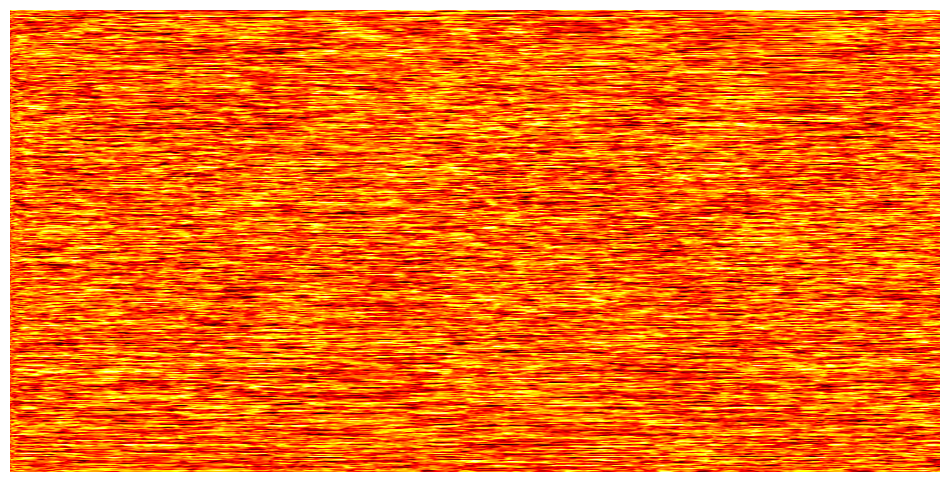

In [47]:
%matplotlib inline
simulator.imshow(cmap='hot', vmin=-1, vmax=1)

In [48]:
save = True
if save:
    np.save('../Results/supp_smoothing_simulations_timeseries1.npy', simulator.timeseries)

In [ ]:
%matplotlib qt
simulator.animate(alpha=0.75,
                 cmap='hot',
                 vmin=-1,
                 vmax=1)

In [7]:
C = simulator.compute_average_correlations(n_iters=100, T=1000, smoothing=False)

100%|█████████████████████████████████████████| 100/100 [00:56<00:00,  1.77it/s]


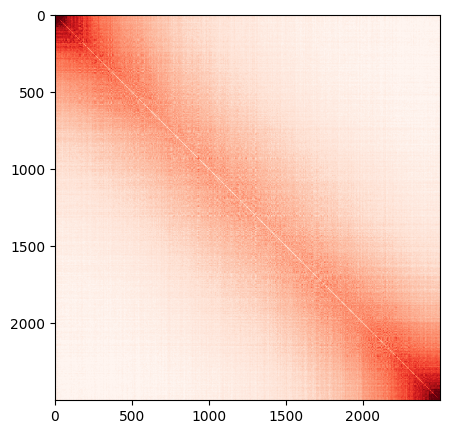

In [8]:
%matplotlib inline
plt.figure(figsize=(5, 5))
plt.imshow(C, cmap='Reds', vmin=0.1, vmax=0.2, interpolation=None)

In [9]:
save = True
if save:
    np.save('../Results/supp_smoothing_simulations_correlations1.npy', C)

In [10]:
mode_similarity, mapping, functional_gradients = simulator.compute_geometric_mapping(C, N_modes=50, return_gradients=True)

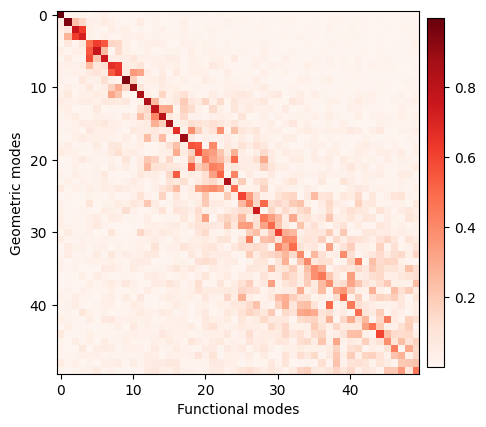

In [11]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(5, 5))
cax = plt.imshow(np.abs(mode_similarity), cmap='Reds')
plt.xlabel('Functional modes')
plt.ylabel('Geometric modes')
plt.colorbar(cax, ax=ax, fraction=0.045, pad=0.02)

#### $\sigma=0.025$

In [12]:
simulator.integrate(4000, output=False)

In [13]:
simulator.timeseries.shape

(2500, 4001)

In [14]:
simulator.timeseries = zscore(spatial_smoothing(simulator.timeseries, simulator.coordinates, sigma=0.025), axis=1)

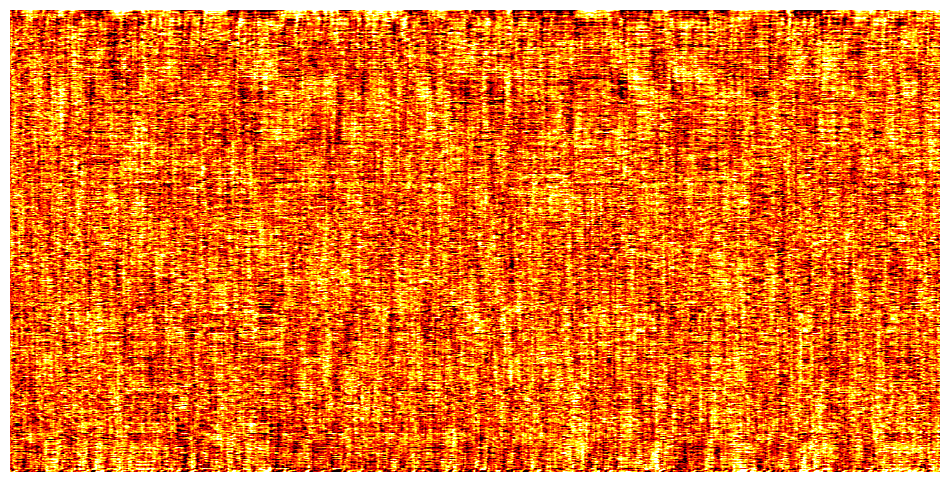

In [15]:
%matplotlib inline
simulator.imshow(cmap='hot', vmin=-1, vmax=1)

In [16]:
save = True
if save:
    np.save('../Results/supp_smoothing_simulations_timeseries2.npy', simulator.timeseries)

In [ ]:
%matplotlib qt
simulator.animate(alpha=0.75,
                 cmap='hot',
                 vmin=-1,
                 vmax=1)

In [17]:
C = simulator.compute_average_correlations(n_iters=100, T=1000, smoothing=True, sigma=0.025)

100%|█████████████████████████████████████████| 100/100 [01:45<00:00,  1.05s/it]


In [18]:
save = True
if save:
    np.save('../Results/supp_smoothing_simulations_correlations2.npy', C)

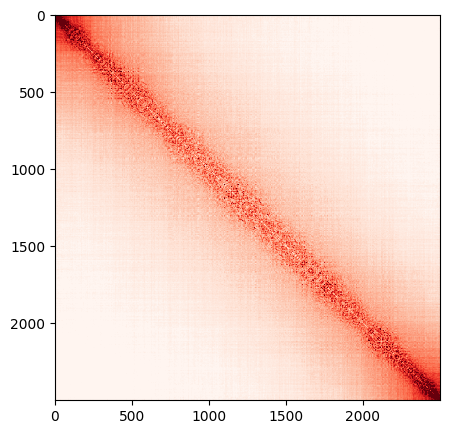

In [19]:
%matplotlib inline
plt.figure(figsize=(5, 5))
plt.imshow(C, cmap='Reds', vmin=0.1, vmax=0.2, interpolation=None)

In [20]:
mode_similarity, mapping, functional_gradients = simulator.compute_geometric_mapping(C, N_modes=50, return_gradients=True)

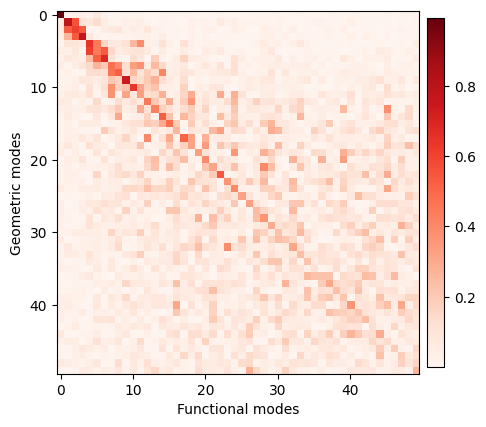

In [21]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(5, 5))
cax = plt.imshow(np.abs(mode_similarity), cmap='Reds')
plt.xlabel('Functional modes')
plt.ylabel('Geometric modes')
plt.colorbar(cax, ax=ax, fraction=0.045, pad=0.02)

#### $\sigma=0.05$

In [22]:
simulator.integrate(1000, output=False)

In [23]:
simulator.timeseries = zscore(spatial_smoothing(simulator.timeseries, simulator.coordinates, sigma=0.05), axis=1)

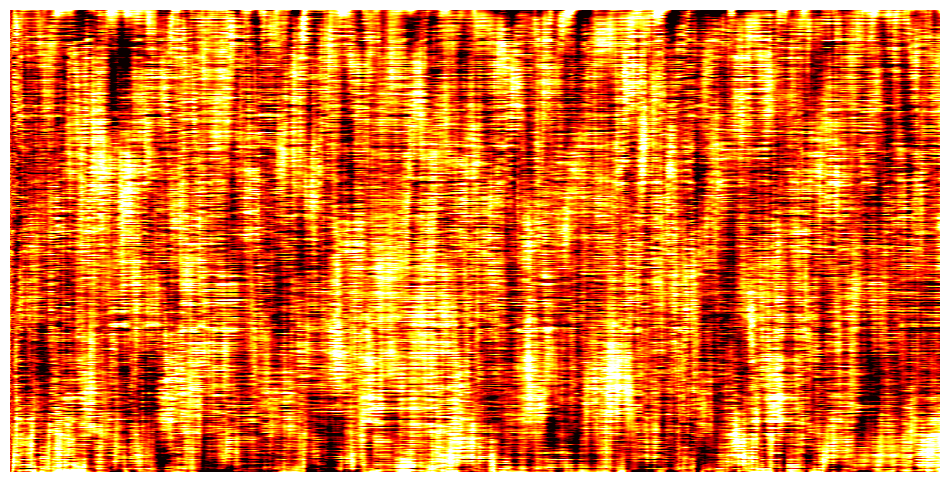

In [24]:
%matplotlib inline
simulator.imshow(cmap='hot', vmin=-1, vmax=1)

In [25]:
save = True
if save:
    np.save('../Results/supp_smoothing_simulations_timeseries3.npy', simulator.timeseries)

In [ ]:
%matplotlib qt
simulator.animate(alpha=0.75,
                 cmap='hot',
                 vmin=-1,
                 vmax=1)

In [26]:
C = simulator.compute_average_correlations(n_iters=100, T=1000, smoothing=True, sigma=0.05)

100%|█████████████████████████████████████████| 100/100 [01:47<00:00,  1.07s/it]


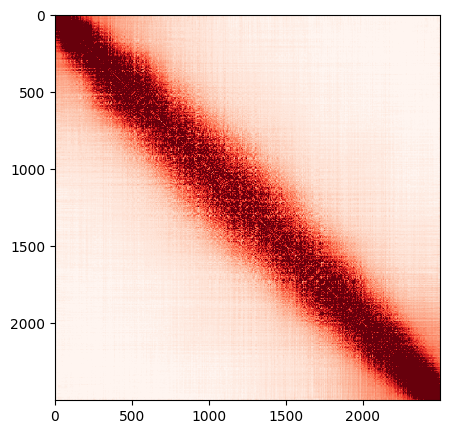

In [27]:
%matplotlib inline
plt.figure(figsize=(5, 5))
plt.imshow(C, cmap='Reds', vmin=0.1, vmax=0.2, interpolation=None)

In [28]:
save = True
if save:
    np.save('../Results/supp_smoothing_simulations_correlations3.npy', C)

In [29]:
mode_similarity, mapping, functional_gradients = simulator.compute_geometric_mapping(C, N_modes=50, return_gradients=True)

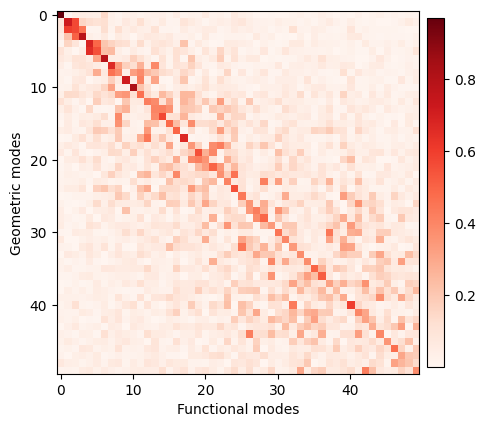

In [30]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(5, 5))
cax = plt.imshow(np.abs(mode_similarity), cmap='Reds')
plt.xlabel('Functional modes')
plt.ylabel('Geometric modes')
plt.colorbar(cax, ax=ax, fraction=0.045, pad=0.02)

#### $\sigma=0.1$

In [49]:
simulator.integrate(1000, output=False)

In [50]:
simulator.timeseries = zscore(spatial_smoothing(simulator.timeseries, simulator.coordinates, sigma=0.1), axis=1)

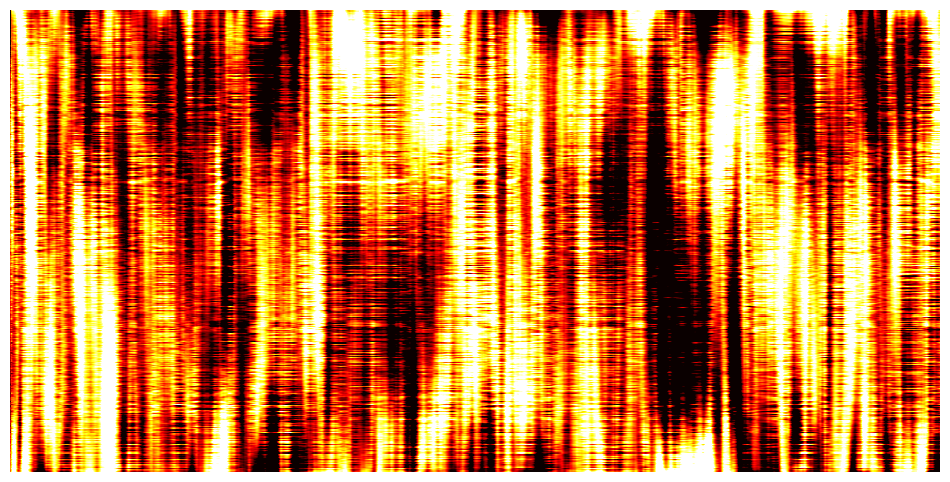

In [51]:
%matplotlib inline
simulator.imshow(cmap='hot', vmin=-1, vmax=1)

In [52]:
save = True
if save:
    np.save('../Results/supp_smoothing_simulations_timeseries4.npy', simulator.timeseries)

In [ ]:
%matplotlib qt
simulator.animate(alpha=0.75,
                 cmap='hot',
                 vmin=-1,
                 vmax=1)

In [35]:
C = simulator.compute_average_correlations(n_iters=100, T=1000, smoothing=True, sigma=0.1)

100%|█████████████████████████████████████████| 100/100 [01:58<00:00,  1.19s/it]


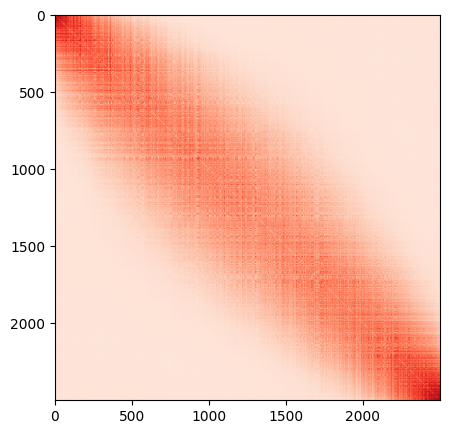

In [36]:
%matplotlib inline
plt.figure(figsize=(5, 5))
plt.imshow(C, cmap='Reds')

In [37]:
save = True
if save:
    np.save('../Results/supp_smoothing_simulations_correlations4.npy', C)

In [38]:
mode_similarity, mapping, functional_gradients = simulator.compute_geometric_mapping(C, N_modes=50, return_gradients=True)

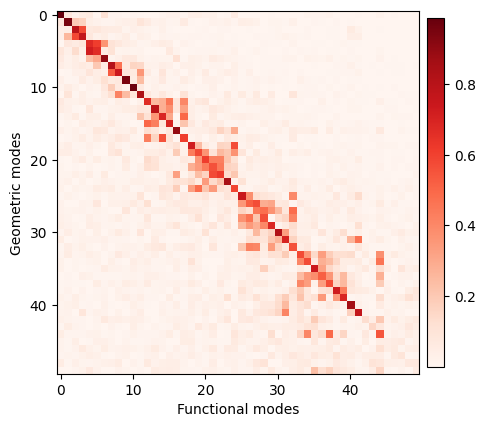

In [39]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(5, 5))
cax = plt.imshow(np.abs(mode_similarity), cmap='Reds')
plt.xlabel('Functional modes')
plt.ylabel('Geometric modes')
plt.colorbar(cax, ax=ax, fraction=0.045, pad=0.02)

# Combined effects of $h$ and $\sigma$ - Parameter sweep

The code was run on Compute Canada for roughly 24 hours. It is located in the `ComputeCanada/filtering/` folder.

In [30]:
corrs = np.load('../ComputeCanada/filtering/mode_correlations_h_and_sigma.npy')
corrs1 = np.load('../ComputeCanada/filtering/mode_correlations_h_and_sigma_part1.npy')
corrs2 = np.load('../ComputeCanada/filtering/mode_correlations_h_and_sigma_part2.npy')
corrs3 = np.load('../ComputeCanada/filtering/mode_correlations_h_and_sigma_part3.npy')
corrs4 = np.load('../ComputeCanada/filtering/mode_correlations_h_and_sigma_part4.npy')
corrs5 = np.load('../ComputeCanada/filtering/mode_correlations_h_and_sigma_part5.npy')
corrs = np.flip(np.concatenate([corrs1, corrs2, corrs3, corrs4, corrs5], axis=1), axis=0)

In [26]:
corrs = np.load('../ComputeCanada/filtering/mode_correlations_h_and_sigma.npy')

In [31]:
grid = np.zeros((20, 20))

for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        values = []
        for k in range(10):
            diag = np.diag(corrs[i, j, k])
            values.append(np.mean(np.abs(diag)[:20]))
        grid[i, j] = np.mean(values)

In [32]:
sigma_values = np.linspace(0, 0.1, 20, endpoint=True)

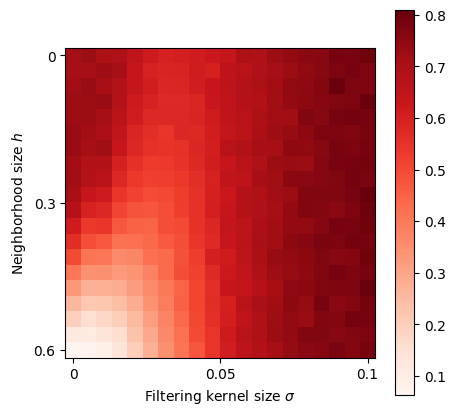

In [33]:
fig, ax = plt.subplots(figsize=(5, 5))
plt.imshow(grid, cmap='Reds')
ax.set_yticks([0, 9.5, 19], [0, 0.3, 0.6])
ax.set_xticks([0, 9.5, 19], [0, 0.05, 0.1])
ax.set_ylabel('Neighborhood size $h$')
ax.set_xlabel('Filtering kernel size $\sigma$')
plt.colorbar()

In [34]:
from visualization import *
from scipy.ndimage import gaussian_filter1d

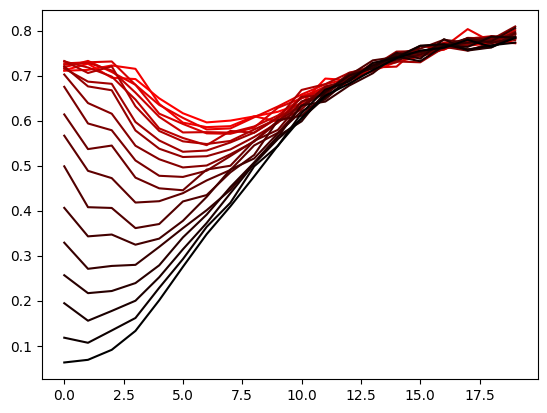

In [35]:
colors = color_gradient([1,0,0], [0,0,0], 20)

for i in range(20):
    plt.plot(grid[i, :], color=colors[i])

#### Plotting matrices at key points along the array

In [36]:
matrix = np.mean(np.abs(corrs[0, 0]), axis=0)

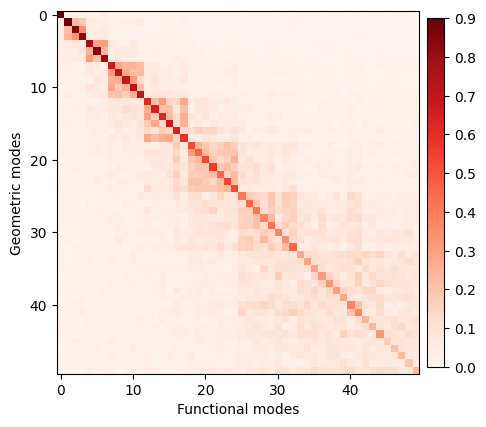

In [37]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(5, 5))
cax = plt.imshow(matrix, cmap='Reds', vmin=0, vmax=0.9)
plt.xlabel('Functional modes')
plt.ylabel('Geometric modes')
plt.colorbar(cax, ax=ax, fraction=0.045, pad=0.02)

In [38]:
np.save('../Results/supp_smoothing_simulations_mode_similarity1.npy', matrix)

In [39]:
matrix = np.mean(np.abs(corrs[0, 7]), axis=0)

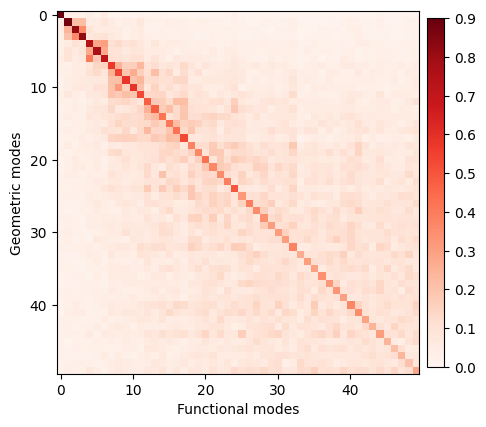

In [40]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(5, 5))
cax = plt.imshow(matrix, cmap='Reds', vmin=0, vmax=0.9)
plt.xlabel('Functional modes')
plt.ylabel('Geometric modes')
plt.colorbar(cax, ax=ax, fraction=0.045, pad=0.02)

In [41]:
np.save('../Results/supp_smoothing_simulations_mode_similarity2.npy', matrix)

In [42]:
matrix = np.mean(np.abs(corrs[0, -1]), axis=0)

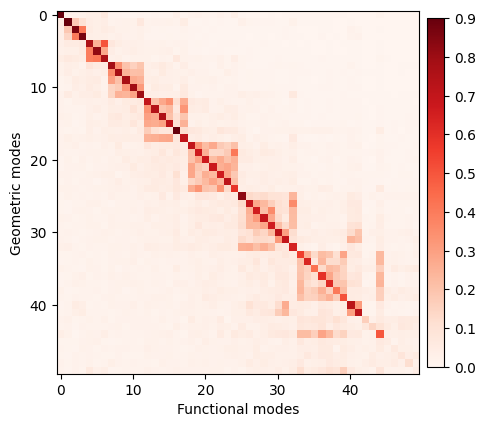

In [43]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(5, 5))
cax = plt.imshow(matrix, cmap='Reds', vmin=0, vmax=0.9)
plt.xlabel('Functional modes')
plt.ylabel('Geometric modes')
plt.colorbar(cax, ax=ax, fraction=0.045, pad=0.02)

In [44]:
np.save('../Results/supp_smoothing_simulations_mode_similarity3.npy', matrix)

# Rendering figure

In [ ]:
timeseries, correlations = [], []
for i in range(4):
    timeseries.append(np.load(f'../Results/supp_smoothing_simulations_timeseries{i+1}.npy'))
    correlations.append(np.load(f'../Results/supp_smoothing_simulations_correlations{i+1}.npy'))

#corrs = np.load('../ComputeCanada/filtering/mode_correlations_h_and_sigma.npy')
corrs = np.load('../ComputeCanada/filtering/mode_correlations_h_and_sigma.npy')
corrs1 = np.load('../ComputeCanada/filtering/mode_correlations_h_and_sigma_part1.npy')
corrs2 = np.load('../ComputeCanada/filtering/mode_correlations_h_and_sigma_part2.npy')
corrs3 = np.load('../ComputeCanada/filtering/mode_correlations_h_and_sigma_part3.npy')
corrs4 = np.load('../ComputeCanada/filtering/mode_correlations_h_and_sigma_part4.npy')
corrs5 = np.load('../ComputeCanada/filtering/mode_correlations_h_and_sigma_part5.npy')
corrs = np.flip(np.concatenate([corrs1, corrs2, corrs3, corrs4, corrs5], axis=1), axis=0)

grid = np.zeros((20, 20))
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        values = []
        for k in range(10):
            diag = np.diag(corrs[i, j, k])
            values.append(np.mean(np.abs(diag)[:20]))
        grid[i, j] = np.mean(values)

mode_similarity = []
for i in range(3):
    mode_similarity.append(np.load(f'../Results/supp_smoothing_simulations_mode_similarity{i+1}.npy'))

In [ ]:
fig = PaperFigure(figsize=(7, 5))

fig.set_tick_length(2)
fig.set_font_size(6)
fig.add_background()

# Setting up axes -------------------------------------------------------------------------------------------------

w = 1.65
pad = (7 - 4 * w) / 3
for i in range(4):
    fig.add_axes(f'timeseries{i}', (i * (w + pad), 0), w, 1)

for i in range(4):
    fig.add_axes(f'correlations{i}', (i * (w + pad), 1.5), 1, 1)

fig.add_axes('grid', (0, 3), w, w)
fig.add_axes('curves', (w + 0.5, 3 + (0.25 * w)), w, w * 0.75)

w2 = 0.8
fig.add_axes('mode_similarity1', (7 - 3 * w2, 3 + w - w2), w2, w2)
fig.add_axes('mode_similarity2', (7 - 2 * w2, 3 + w - w2), w2, w2)
fig.add_axes('mode_similarity3', (7 - 1 * w2, 3 + w - w2), w2, w2)

fig.set_line_thickness(0.6)

# Filling content --------------------------------------------------------------------------------------------------

for i in range(4):
    ax = fig.axes[f'timeseries{i}']
    ax.imshow(zscore(timeseries[i][:, :1000], axis=1), cmap='binary', vmin=-0.5, vmax=1.5, aspect='auto')
    ax.set_xticks([])
    ax.set_yticks([])

for i in range(4):
    ax = fig.axes[f'correlations{i}']
    ax.imshow(correlations[i], cmap='Reds', vmin=np.percentile(correlations[i], 5), vmax=np.percentile(correlations[i], 95), aspect='auto')
    ax.set_xticks([])
    ax.set_yticks([])
    print(np.percentile(correlations[i], 5), np.percentile(correlations[i], 95))

ax = fig.axes['grid']
ax.imshow(grid, cmap='Reds')

ax = fig.axes['curves']
ax.spines[['top', 'right']].set_visible(False)
red = plt.get_cmap('Reds')(175)[:3]
beige = plt.get_cmap('Reds')(50)[:3]
colors = color_gradient(red, beige, 20)
x = np.linspace(0, 0.1, 20, endpoint=True)
for i in range(20):
    ax.plot(x, gaussian_filter1d(grid[i, :], 1), color=colors[i])
ax.set_xticks([0, 0.05, 0.1])
ax.set_xlim([0, 0.1])

for i in range(3):
    ax = fig.axes[f'mode_similarity{i+1}']
    ax.imshow(mode_similarity[i], cmap='Reds', vmin=0, vmax=1)
    ax.set_xticks([])
    ax.set_yticks([])

fig.show()

In [ ]:
fig.save('../Figures/supp_smoothing_simulations_incomplete.svg')